In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df=pd.read_csv("c:\\Users\\a\\Downloads\\spam.csv",encoding="latin1")

In [18]:
df.drop(columns=["Unnamed: 2","Unnamed: 3","Unnamed: 4"],inplace=True)

In [19]:
df=df.rename(columns={"v1":"traget","v2":"text"})

In [20]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()

In [21]:
df["traget"]=encoder.fit_transform(df["traget"])

In [22]:
df.head()

,traget,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
df.isnull().sum()

traget    0
text      0
dtype: int64

In [24]:
df.duplicated().sum()

np.int64(403)

In [25]:
df=df.drop_duplicates(keep="first")

In [26]:
df["traget"].value_counts()

traget
0    4516
1     653
Name: count, dtype: int64

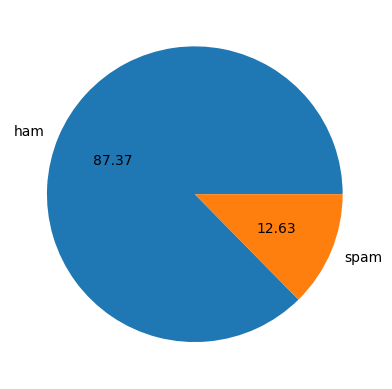

In [27]:
plt.pie(df["traget"].value_counts(),labels=["ham","spam"],autopct="%0.2f")
plt.show()

In [28]:
df["num_characters"]=df["text"].apply(len)

In [29]:
import nltk

In [30]:
df["num_words"]=df["text"].apply(lambda x:len(nltk.word_tokenize(x)))

In [31]:
df["num_sentences"]=df["text"].apply(lambda x:len(nltk.sent_tokenize(x)))

In [32]:
df.head()

,traget,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [33]:
df.describe()

,traget,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,0.126330,78.977945,18.455794,1.965564
std,0.332253,58.236293,13.324758,1.448541
min,0.000000,2.000000,1.000000,1.000000
25%,0.000000,36.000000,9.000000,1.000000
50%,0.000000,60.000000,15.000000,1.000000
75%,0.000000,117.000000,26.000000,2.000000
max,1.000000,910.000000,220.000000,38.000000


In [34]:
# spam
df[df["traget"]==1][["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [35]:
#ham
df[df["traget"]==0][["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


<Axes: xlabel='num_characters', ylabel='Count'>

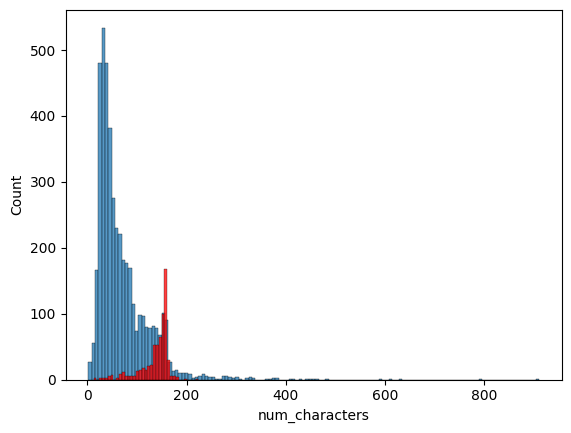

In [36]:
plt.Figure(figsize=(12,6))
sns.histplot(df[df["traget"]==0]["num_characters"])
sns.histplot(df[df["traget"]==1]["num_characters"],color="red")

<Axes: xlabel='num_words', ylabel='Count'>

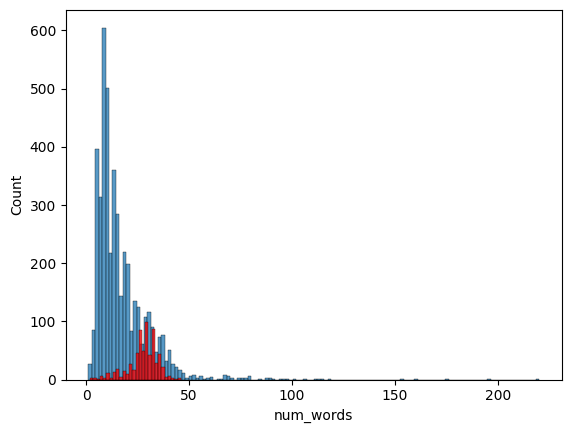

In [37]:
plt.Figure(figsize=(12,6))
sns.histplot(df[df["traget"]==0]["num_words"])
sns.histplot(df[df["traget"]==1]["num_words"],color="red")

In [38]:
dp=df.corr(numeric_only=True)

<Axes: >

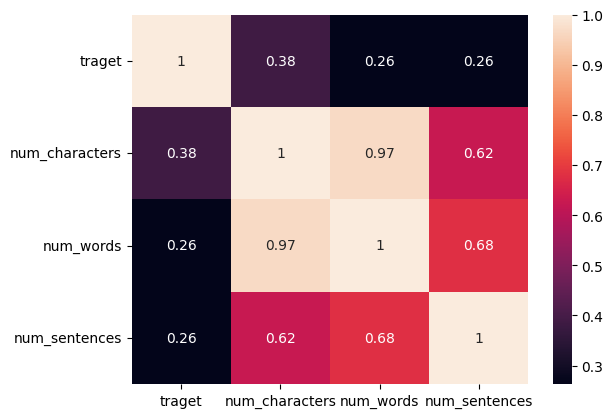

In [39]:
sns.heatmap(dp,annot=True)

data preprocessing
>Lower case
>Tokeniation
>Removing stop word and punctuation 
>Removing special characters
>stemming

In [40]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\a\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [41]:
from nltk.corpus import stopwords


In [42]:
import string

In [43]:
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()

In [44]:
def tansform_text(text):
  text=text.lower()
  text=nltk.word_tokenize(text)
  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)
  text=y[:]
  y.clear()
  for i in text:
    if i not in stopwords.words("english") and i not in string.punctuation:
      y.append(i)
  text=y[:]
  y.clear()
  for i in text :
    y.append(ps.stem(i))
  return " ".join(y)
  
    
    

In [45]:
df["tansformed_text"]=df["text"].apply(tansform_text)

In [46]:
df.head()

,traget,text,num_characters,num_words,num_sentences,tansformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [47]:
from wordcloud import WordCloud
wc=WordCloud(width=500,height=500,min_font_size=10,background_color="white")

In [48]:
spam_wc=wc.generate(df[df["traget"]==1]["tansformed_text"].str.cat(sep=" "))

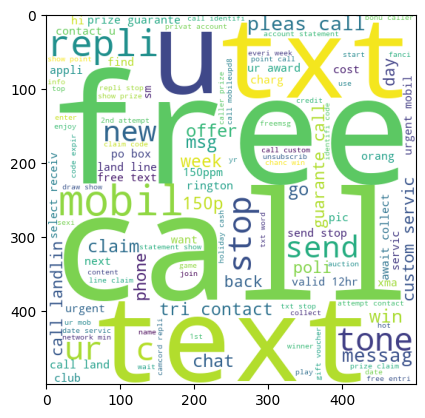

In [49]:
plt.imshow(spam_wc)

In [50]:
ham_wc=wc.generate(df[df["traget"]==0]["tansformed_text"].str.cat(sep=" "))

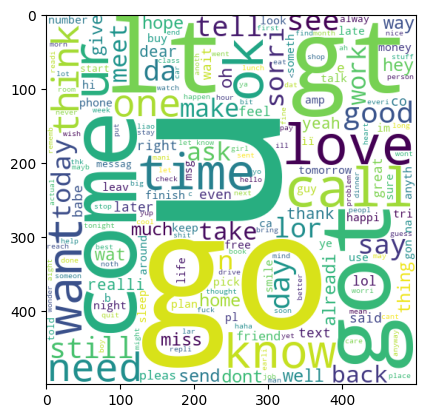

In [51]:
plt.imshow(ham_wc)

In [52]:
spam_corpus=[]
for msg in df[df["traget"]==1]["tansformed_text"].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [53]:
len(spam_corpus)

9939

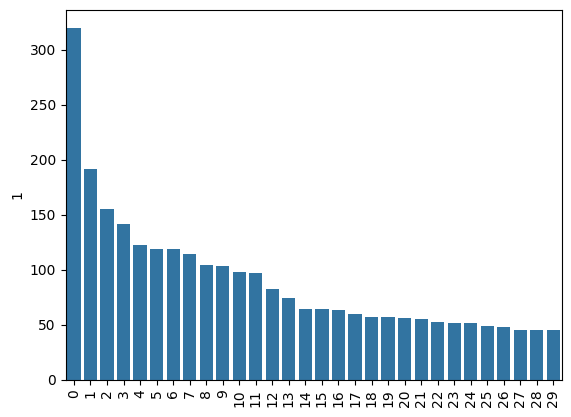

In [54]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(spam_corpus).most_common(30))[1])
plt.xticks(rotation="vertical")
plt.show()


In [55]:
ham_corpus=[]
for msg in df[df["traget"]==0]["tansformed_text"].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [56]:
len(ham_corpus)

35404

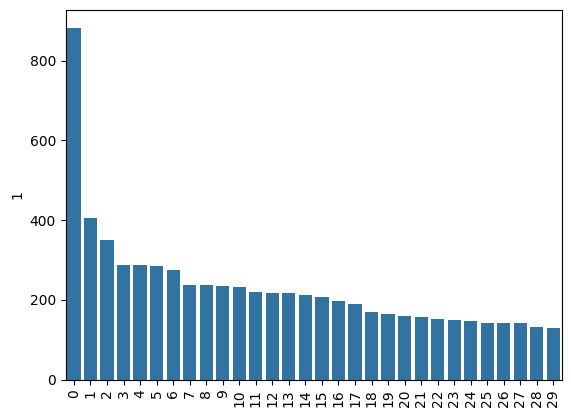

In [57]:
from collections import Counter
sns.barplot(pd.DataFrame(Counter(ham_corpus).most_common(30))[1])
plt.xticks(rotation="vertical")
plt.show()

Model bilds

In [58]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv=CountVectorizer()
tp=TfidfVectorizer(max_features=3000)

In [59]:
X=tp.fit_transform(df["tansformed_text"]).toarray()

In [60]:
X.shape

(5169, 3000)

In [61]:
y=df["traget"].values

In [62]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [63]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [64]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()


In [65]:
gnb.fit(X_train,y_train)
y_pred1=gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8588007736943907
[[782 121]
 [ 25 106]]
0.4669603524229075


In [66]:
mnb.fit(X_train,y_train)
y_pred2=mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9748549323017408
[[901   2]
 [ 24 107]]
0.981651376146789


In [67]:
bnb.fit(X_train,y_train)
y_pred3=bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[902   1]
 [ 16 115]]
0.9913793103448276


In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,ExtraTreesClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier





In [69]:
svc=SVC(kernel="sigmoid",gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
dtc=DecisionTreeClassifier(max_depth=5)
lrc=LogisticRegression(solver="liblinear",penalty="l1")
rfc=RandomForestClassifier(n_estimators=50,random_state=42)
abc=AdaBoostClassifier(n_estimators=50,random_state=42)
bc=BaggingClassifier(n_estimators=50,random_state=42)
etc=ExtraTreesClassifier(n_estimators=50,random_state=42)
gbdt=GradientBoostingClassifier(n_estimators=50,random_state=42)
xgb=XGBClassifier(n_estimators=50,random_state=42)


In [70]:
clfs={
  "svc":svc,
  "KN":knc,
  "NB":mnb,
  "DT":dtc,
  "LR":lrc,
  "RF":rfc,
  "Adaboost":abc,
  "Bgc":bc,
  "ETC":etc,
  "GBDT":gbdt,
  "xgb":xgb
}

In [71]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
  clf.fit(X_train,y_train)
  y_pred=clf.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred)
  return accuracy,precision

In [72]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.97678916827853, 0.9734513274336283)

In [73]:
accuracy=[]
precision=[]
for name,clf in clfs.items():
  current_accuracy,current_precision=train_classifier(clf,X_train,y_train,X_test,y_test)
  print("for",name)
  print("Accuracy",current_accuracy)
  print("Precision",current_precision)
  accuracy.append(current_accuracy)
  precision.append(current_precision)

for svc
Accuracy 0.97678916827853
Precision 0.9734513274336283
for KN
Accuracy 0.9061895551257253
Precision 1.0
for NB
Accuracy 0.9748549323017408
Precision 0.981651376146789
for DT
Accuracy 0.9400386847195358
Precision 0.822429906542056
for LR
Accuracy 0.9584139264990329
Precision 0.94
for RF
Accuracy 0.9748549323017408
Precision 0.981651376146789
for Adaboost
Accuracy 0.9235976789168279
Precision 0.7708333333333334
for Bgc
Accuracy 0.9506769825918762
Precision 0.8076923076923077
for ETC
Accuracy 0.9777562862669246
Precision 0.9655172413793104
for GBDT
Accuracy 0.9574468085106383
Precision 0.9578947368421052
for xgb
Accuracy 0.965183752417795
Precision 0.9203539823008849


In [74]:
performance_df=pd.DataFrame({"Algorithm":clfs.keys(),"Accuracy":accuracy,"precision":precision})

In [75]:
performance_df

,Algorithm,Accuracy,precision
0,svc,0.976789,0.973451
1,KN,0.906190,1.000000
2,NB,0.974855,0.981651
3,DT,0.940039,0.822430
4,LR,0.958414,0.940000
5,RF,0.974855,0.981651
6,Adaboost,0.923598,0.770833
7,Bgc,0.950677,0.807692
8,ETC,0.977756,0.965517
9,GBDT,0.957447,0.957895


In [76]:
import pickle
pickle.dump(tp,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model','wb'))

